# Speech Emotion Recognition using MLPClassifier (TESS Dataset)

## Project Overview
This Jupyter Notebook details the process of building a Speech Emotion Recognition (SER) system. We will leverage the **TESS (Toronto Emotional Speech Set)** dataset to train a Multi-Layer Perceptron (MLP) Classifier to identify various emotions from spoken audio.

## Objective
The primary objective of this project is to accurately classify human emotions from speech signals, demonstrating fundamental skills in audio processing, feature engineering, and supervised machine learning.

## Key Technologies Used
* **Python:** The primary programming language.
* **Jupyter Notebook:** For interactive development and documentation.
* **Librosa:** For audio loading and advanced feature extraction (MFCCs, Chroma, Mel Spectrogram, etc.).
* **Scikit-learn:** For machine learning model (MLPClassifier), data splitting, and evaluation metrics.
* **NumPy & Pandas:** For efficient data manipulation.
* **Matplotlib & Seaborn:** For data visualization and presenting results.

## Dataset
We will be using the **TESS (Toronto Emotional Speech Set)** dataset.
* **Download Link:** [TESS Dataset on Kaggle](https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess) (You'll need a Kaggle account to download, which is free).
* **Dataset Structure:** After downloading `TESS_Toronto_emotional_speech_set_data.zip` and unzipping, you'll find folders for each emotion (e.g., `OAF_fear`, `YAF_sad`). The file names encode the speaker (OAF/YAF) and the emotion.
* **Unzip Location:** Place the unzipped `TESS_Toronto_emotional_speech_set_data` (or rename it to just `TESS` for simplicity) folder in the same directory as this notebook.

## TESS File Naming Convention
Each filename directly contains the emotion label.
Example: `OAF_base_sad.wav`
* `OAF`: Speaker code (Older Adult Female)
* `base`: Base word
* `sad`: **Emotion** (e.g., angry, disgust, fearful, happy, ps (pleasant surprise), sad, neutral)fearful
* 07 = disgust
* 08 = surprised

# Import Libraries

In [3]:
!pip install librosa sounddevice soundfile numpy pandas scikit-learn matplotlib seaborn tqdm

# Import Modules

In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio

import warnings
warnings.filterwarnings('ignore')
# import soundfile as sf
# import sounddevice as sd

# Load the data

In [5]:
#loading and splitting the file name.
paths=[]
labels=[]
for dirname,_,filenames in os.walk('Data\TESS'):
    for filename in filenames:
        paths.append(os.path.join(dirname,filename))
        label=filename.split('_')[-1]
        label=label.split('.')[-2]
        labels.append(label.lower())
print("Dataset is loaded ✅")
# os.walk is used to traverse the file path like mainfolder(Data)-->TESS folder-
        #      -->emotions-->.wav filepath

Dataset is loaded ✅


In [6]:
paths[:5]

['Data\\TESS\\OAF_angry\\OAF_back_angry.wav',
 'Data\\TESS\\OAF_angry\\OAF_bar_angry.wav',
 'Data\\TESS\\OAF_angry\\OAF_base_angry.wav',
 'Data\\TESS\\OAF_angry\\OAF_bath_angry.wav',
 'Data\\TESS\\OAF_angry\\OAF_bean_angry.wav']

In [7]:
labels[:5]

['angry', 'angry', 'angry', 'angry', 'angry']

### Create a DATAFRAME

In [8]:
df=pd.DataFrame()
df['speech']=paths
df['label']=labels
df.head()

,speech,label
0,Data\TESS\OAF_angry\OAF_back_angry.wav,angry
1,Data\TESS\OAF_angry\OAF_bar_angry.wav,angry
2,Data\TESS\OAF_angry\OAF_base_angry.wav,angry
3,Data\TESS\OAF_angry\OAF_bath_angry.wav,angry
4,Data\TESS\OAF_angry\OAF_bean_angry.wav,angry


In [9]:
df['label'].value_counts()

label
angry      800
disgust    800
fear       800
happy      800
neutral    800
ps         800
sad        800
Name: count, dtype: int64

# Exploratory Data Analysis

<Axes: xlabel='label', ylabel='count'>

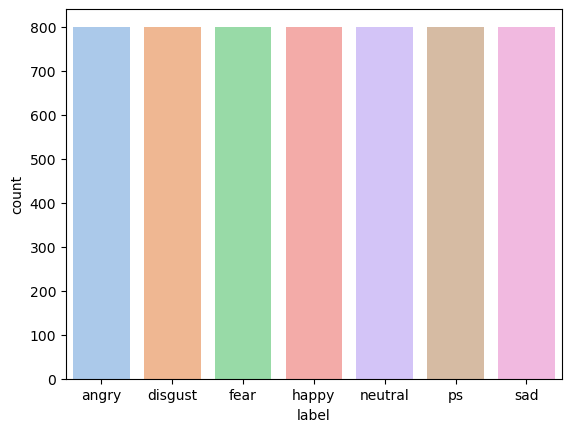

In [10]:
sns.countplot(x='label', data=df, palette='pastel')
#if we want vertical version in the updaed seabore we should give 2 parameters andd for color acccoring to 
#the version it using the default color in my version the color is blue for changing the color we should use the 
                    #prompt "palette" and the color we want.

# Display The Audio and Spectogram

In [11]:
def waveplot(data,sr,emotion):
    plt.figure(figsize=(10,4))# defines the size of a figure
    plt.title(emotion, size=20)# Adds a title to tjhe plot
    librosa.display.waveshow(data,sr=sr)# Draws the audio waveform using the sample rate.
    plt.show()#display the plot
    
def spectrogram(data,sr,emotion):
    x=librosa.stft(data) # Performs Short-Time Fourier Transform (splits sound into time+frequency parts).
    xdb=librosa.amplitude_to_db(abs(x))#converting the file to decibles
    plt.figure(figsize=(12,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb,sr=sr,x_axis='time',y_axis='hz')
    plt.colorbar()# Adds a color bar to show decibel intensity.
    plt.show()

### Displaying ANGRY

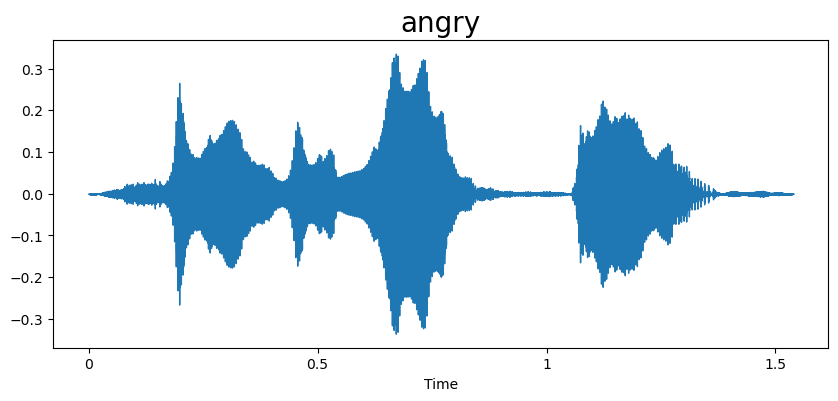

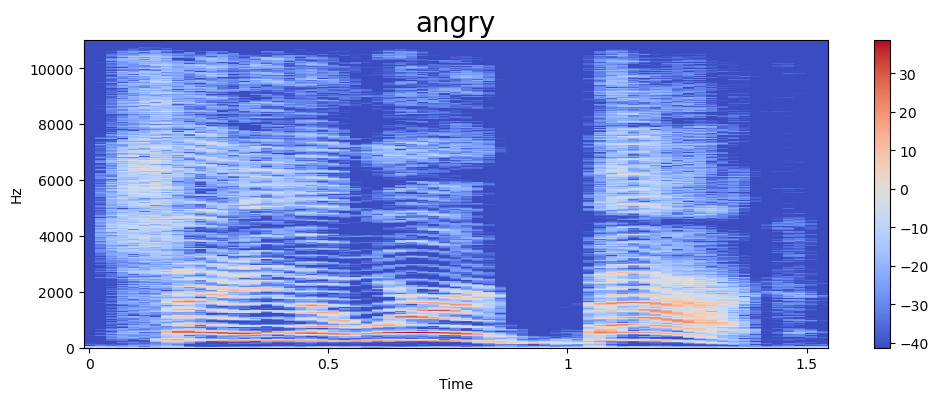

In [12]:
emotion='angry' # Selects the emotion we want to visualize.
path=np.array(df['speech'][df['label']==emotion])[0] # Finds the file path of the first 'angry' audio.
data,sampling_rate=librosa.load(path) # Loads the audio file into 'data' and gets its sample rate.
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path) # Plays the audio file

### Displaying DISGUST

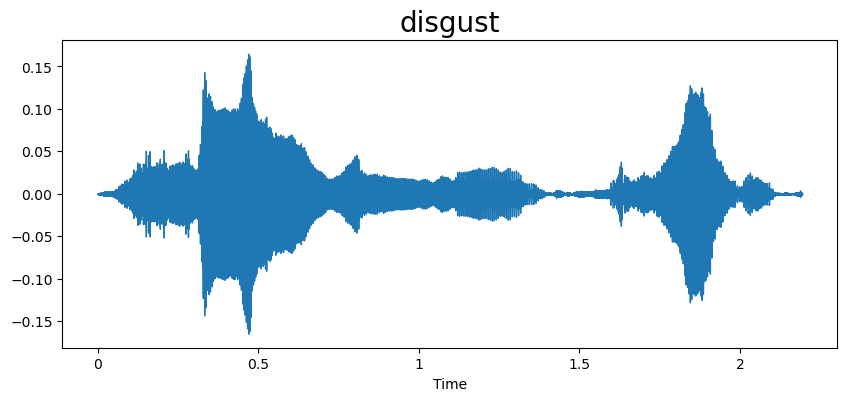

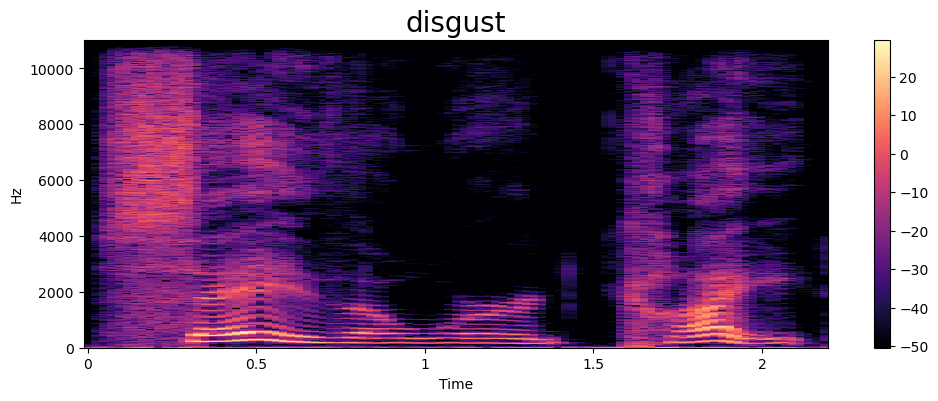

In [13]:
emotion='disgust'
path=np.array(df['speech'][df['label']==emotion])[78]
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

### Displaying FEAR

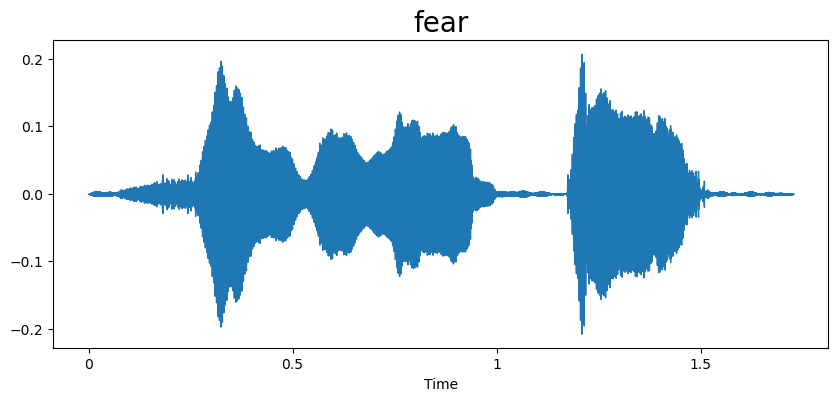

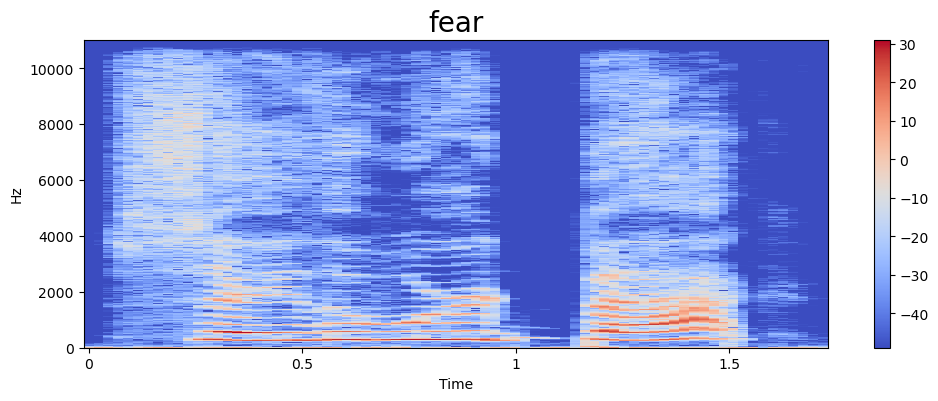

In [14]:
emotion='fear'
path=np.array(df['speech'][df['label']==emotion])[0]
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

### Displaying HAPPY

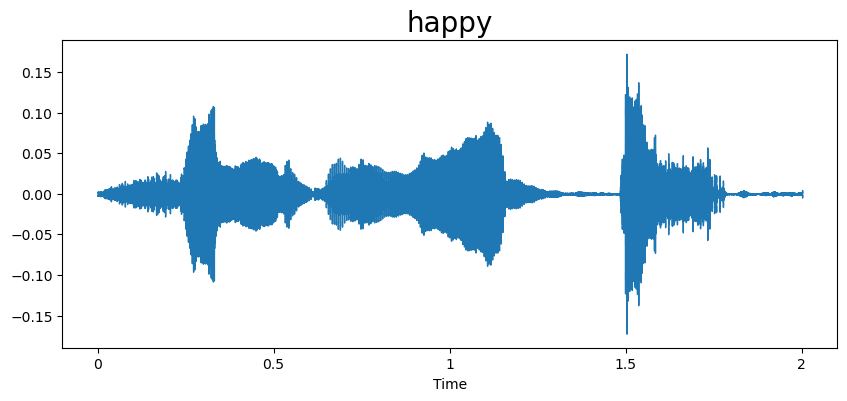

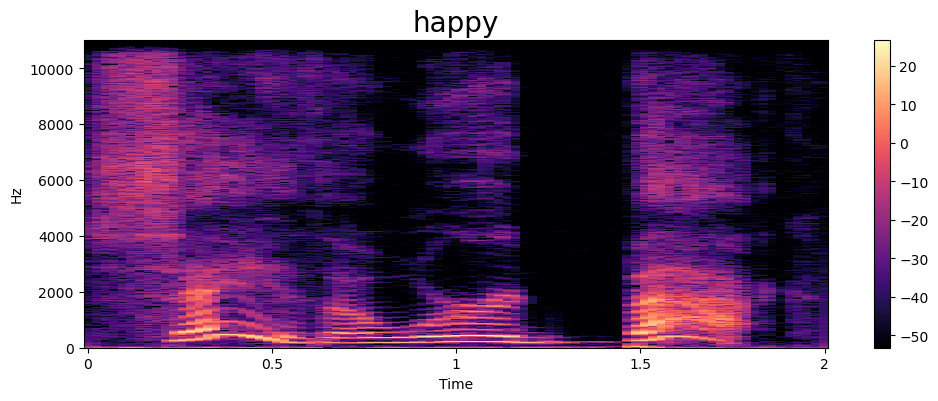

In [15]:
emotion='happy'
path=np.array(df['speech'][df['label']==emotion])[0]
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

### Displaying NEUTRAL

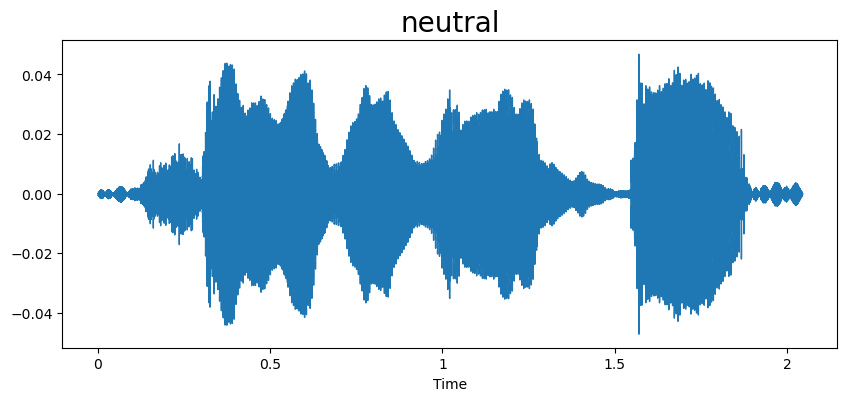

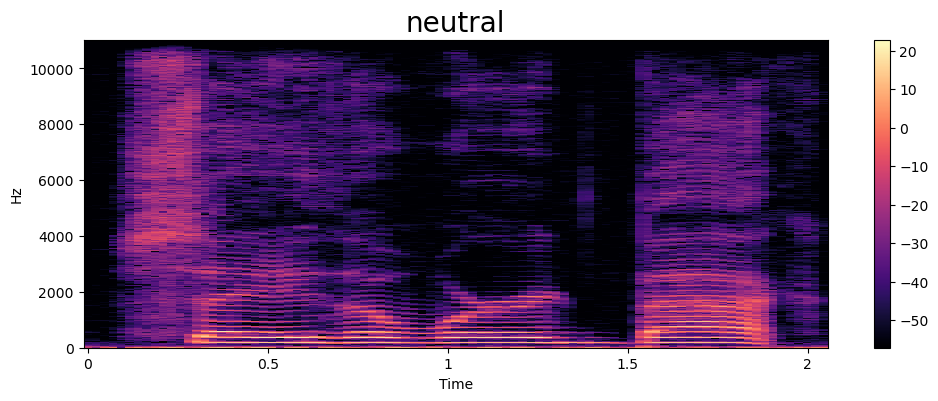

In [16]:
emotion='neutral'
path=np.array(df['speech'][df['label']==emotion])[0]
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

### Displaying PS

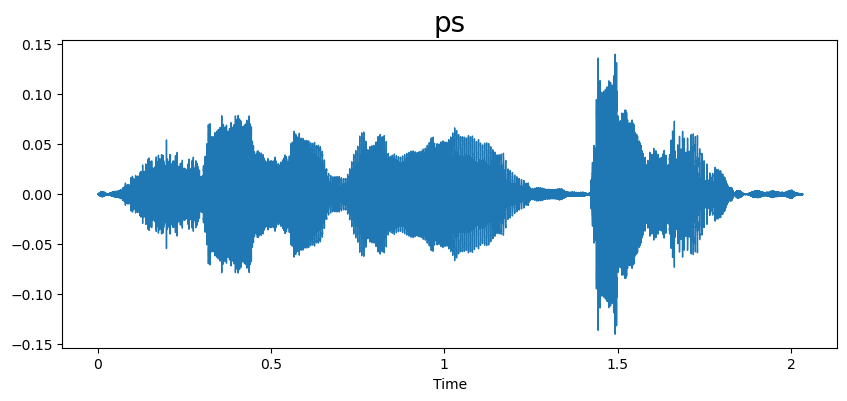

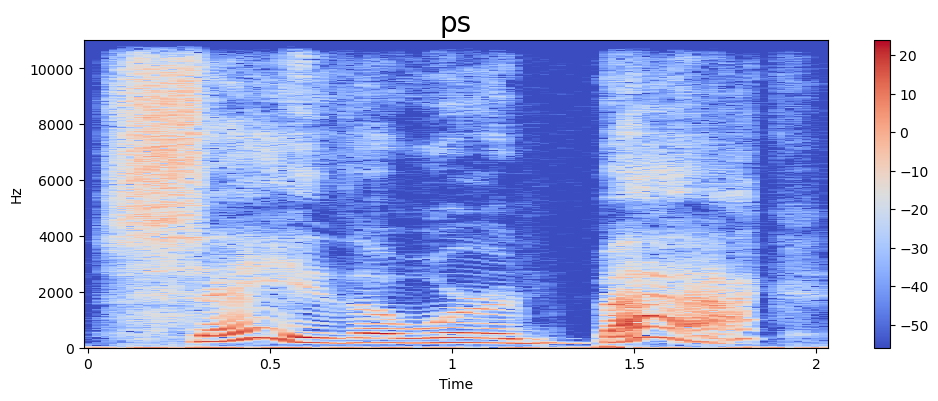

In [17]:
emotion='ps'
path=np.array(df['speech'][df['label']==emotion])[0]
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

### Displaying sad

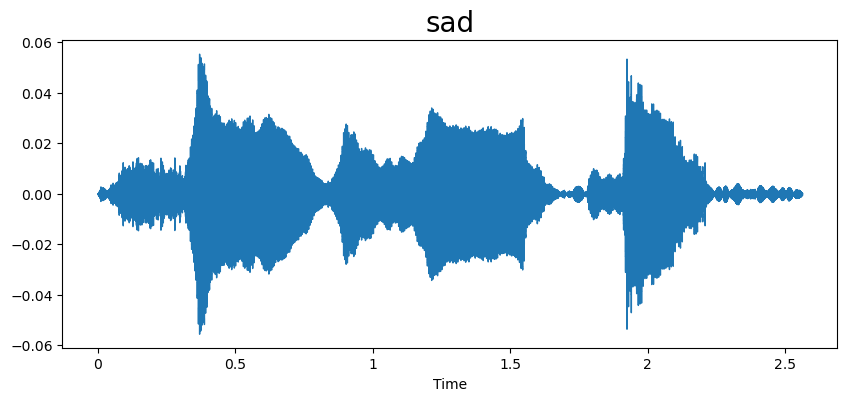

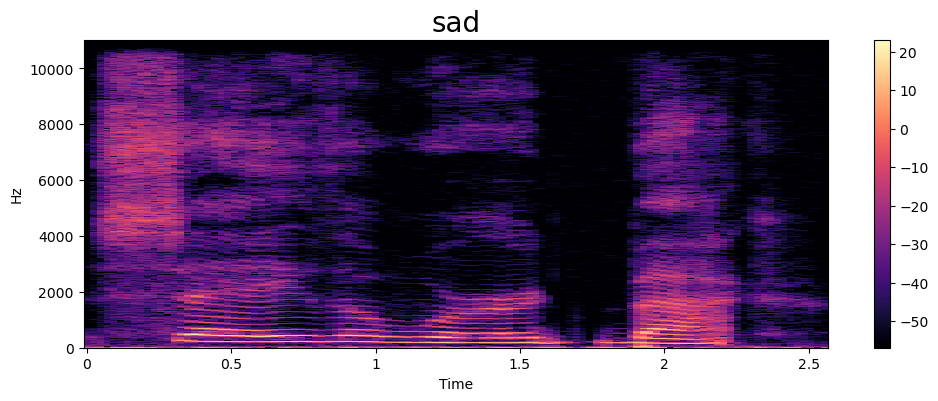

In [18]:
emotion='sad'
path=np.array(df['speech'][df['label']==emotion])[0] #different index for different words
data,sampling_rate=librosa.load(path)
waveplot(data,sampling_rate,emotion)
spectrogram(data,sampling_rate,emotion)
Audio(path)

# Feature Extraction

In [19]:
def extract_mfcc(filename):
    y,sr=librosa.load(filename, duration=3, offset=0.5)
    mfcc=np.mean(librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40).T,axis=0)# extracts 40 MFCC features and get a matrix and transpose it.
          #we also apply mean to the data to convertfrom variable size to fixed size.
    return mfcc

In [20]:
#process done in the above code 
#📂 Audio file paths → 🎵 MFCC features → 📊 NumPy array → 📊 Array with channel dimension

In [21]:
extract_mfcc(df['speech'][0])

array([-3.9698621e+02,  7.7440536e+01, -1.9592791e+01, -2.1666689e+01,
       -2.1127560e+00,  1.0075363e+01, -2.0366707e+01, -6.0924492e+00,
       -7.2122831e+00, -5.5736601e-01, -1.8325533e+00,  2.0210154e-01,
        7.2755075e-01,  1.3177377e+00,  2.8863375e+00,  2.8557909e+00,
       -4.7129216e+00, -4.4365106e+00, -1.6211596e+00, -1.0239839e+01,
       -7.5512629e+00, -1.7968802e+00, -7.0376525e+00,  9.4365835e+00,
        8.3558550e+00,  2.1712360e+01,  1.9216991e+01,  2.0348930e+01,
        1.3413366e+01,  8.3391724e+00,  3.9472219e-01,  5.1113148e+00,
        9.5687389e+00,  5.4548678e+00,  2.5099635e+00, -1.8239073e+00,
        4.8689623e+00,  9.3139238e+00,  2.0891502e+00, -1.9064913e+00],
      dtype=float32)

In [22]:
X_mfcc=df['speech'].apply(lambda x:extract_mfcc(x))# extracting mfcc feature for all the paths of the audio file and store it.

In [23]:
X_mfcc # display the stored result but not in numpy format

0       [-396.9862, 77.44054, -19.59279, -21.666689, -...
1       [-465.73267, 98.77373, 0.6560085, -32.74544, -...
2       [-429.79196, 46.124, 1.5550478, -0.21709459, 2...
3       [-403.46118, 76.32369, -12.531775, -22.288858,...
4       [-434.05756, 77.4455, 10.8654995, 16.092943, 8...
                              ...                        
5595    [-406.48053, 80.379875, 32.462395, 46.579094, ...
5596    [-426.90918, 102.54756, 24.800041, 43.048096, ...
5597    [-378.50494, 80.91062, 35.300533, 39.74792, -4...
5598    [-434.8618, 89.90637, 28.373262, 39.577065, -2...
5599    [-421.8341, 70.69788, 32.476387, 45.642555, 4....
Name: speech, Length: 5600, dtype: object

In [24]:
X=[x for x in X_mfcc] # taking each value of MFCC and storing it in list
X=np.array(X) #converting list to numpy array so easy to handle ml models.
X.shape #rows = audio files, columns = features.

(5600, 40)

In [25]:
## Input Split
X=np.expand_dims(X,-1)
X.shape #32:29

(5600, 40, 1)

### One-Hot Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder()
y=enc.fit_transform(df[['label']])
                #uses double brackets to pass a 2D column (a DataFrame) as scikit-learn expects shape (n_samples, n_features)

In [27]:
y=y.toarray() #Converts the sparse matrix to a dense NumPy array
y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [28]:
y.shape # samples(rows),emotions(col)

(5600, 7)

# Create the LSTM Model

### LSTM MODEL : Designed to work with time-series data

In [29]:
import tensorflow as tf
from tensorflow import keras

In [30]:
from keras.models import Sequential # to stack layers in order
from keras.layers import Dense , LSTM, Dropout
    #1.fully connected layer 2.for sequence and time series data  3.Turns off random neurons during training to prevent overfitting.
model=Sequential([
        LSTM(123,return_sequences=False,input_shape=(40,1)),
        # LSTM neurons,Only give the final output 2.(MFCC features) and 1 channel like before.
        Dense(64,activation='relu'),#avoids negative influence from negative values.
        Dropout(0.2),
        Dense(32,activation='relu'),
        Dropout(0.2),
        Dense(7,activation='softmax'),#Output layer with 7 neurons — one for each emotion class.
])
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
            #for multi-class classificartion, Efficient optimizer that adjusts learning rate automatically.
model.summary()
    

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 123)                 │          61,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 71,747 (280.26 KB)

 Trainable params: 71,747 (280.26 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
#train the model
history = model.fit(X,y,validation_split=0.2,epochs=100,batch_size=512,shuffle=True)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9596 - loss: 0.1174 - val_accuracy: 0.9955 - val_loss: 0.0139
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9626 - loss: 0.0998 - val_accuracy: 0.9964 - val_loss: 0.0140
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9602 - loss: 0.1169 - val_accuracy: 0.9973 - val_loss: 0.0124
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9606 - loss: 0.1116 - val_accuracy: 0.9955 - val_loss: 0.0130
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9599 - loss: 0.1135 - val_accuracy: 0.9964 - val_loss: 0.0124
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9675 - loss: 0.0941 - val_accuracy: 0.9973 - val_loss: 0.0120
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9700 - loss: 0.0954 - val_accuracy: 0.9955 - val_loss: 0.0125
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9664 - loss: 0.0897 - val_accuracy: 0.9946 - val_loss:

# Plot the RESULT

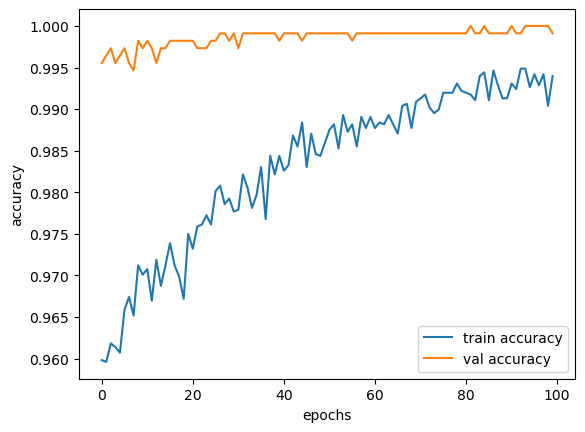

In [47]:
epochs=list(range(100))
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

plt.plot(epochs,acc,label='train accuracy')
plt.plot(epochs,val_acc,label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

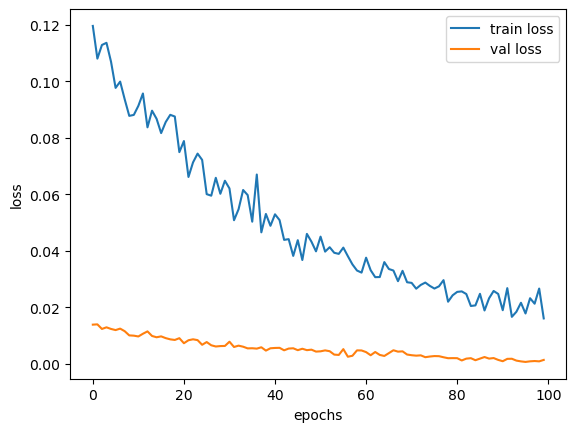

In [48]:
loss=history.history['loss']
val_loss=history.history['val_loss']

plt.plot(epochs,loss,label='train loss')
plt.plot(epochs,val_loss,label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [44]:
# X = X.astype('float32')
# y = y.astype('float32')


In [45]:
# from keras.models import Sequential
# from keras.layers import Dense, Dropout

# model = Sequential()
# model.add(Dense(256, input_shape=(X.shape[1],), activation='relu'))
# model.add(Dropout(0.3))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.3))
# model.add(Dense(y.shape[1], activation='softmax'))

# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
#got error in the above code like getting nans value in val_acc and loss value as 0

In [37]:
# Predict class probabilities
y_pred_probs = model.predict(X)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot true labels to class labels if necessary
y_true = np.argmax(y, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [49]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", round(acc * 100, 2), "%")

# F1 Score (macro-averaged)
f1 = f1_score(y_true, y_pred, average='macro')
print("F1 Score (macro):", round(f1, 4))

# Full classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Accuracy: 99.43 %
F1 Score (macro): 0.9943

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       800
           1       0.98      1.00      0.99       800
           2       1.00      1.00      1.00       800
           3       0.98      1.00      0.99       800
           4       1.00      1.00      1.00       800
           5       1.00      0.96      0.98       800
           6       1.00      1.00      1.00       800

    accuracy                           0.99      5600
   macro avg       0.99      0.99      0.99      5600
weighted avg       0.99      0.99      0.99      5600



In [50]:
# # Compute confusion matrix
# cm = confusion_matrix(y_true, y_pred)

# # Plot it
# plt.figure(figsize=(10, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.show()


In [51]:
# from sklearn.metrics import ConfusionMatrixDisplay

# # Replace with your actual emotion labels
# labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

# ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap='Blues', xticks_rotation=45)
# plt.title("Confusion Matrix with Labels")
# plt.show()


In [ ]:
 #Predicting own voice

In [52]:
# import sounddevice as sd
# import soundfile as sf

# def record_audio(filename, duration=4, samplerate=22050):
#     print(f"🎤 Recording for {duration} seconds...")
#     audio = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1)
#     sd.wait()
#     sf.write(filename, audio, samplerate)
#     print(f"✅ Recording saved as: {filename}")

In [53]:
# record_audio("Test/my_voice.wav", duration=4)

In [54]:
# predict_emotion("Test/my_voice.wav")